<a href="https://colab.research.google.com/github/braltoids0089/BIOMEDICINE/blob/main/(%2B%2B)Digital_Twin_Workflow_From_Gene_Expression_to_Pathway_Analysis_Guided_Drug_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Digital Twin Workflow: From Gene Expression to Pathway Analysis-Guided Drug Selection**

**A. Introduction**

This notebook demonstrates a workflow for identifying potential drug therapies for cancer patients based on their gene expression data. The approach involves:
- Loading and processing gene expression data (TPM values) from the Toil database.
- Focusing on a subset of genes relevant to predefined signaling pathways.
- Performing Principal Component Analysis (PCA) for dimensionality reduction and visualization of samples (Tumor vs Normal).
- Scoring the activity of selected signaling pathways for each patient.
- Formulating a Quadratic Unconstrained Binary Optimization (QUBO) problem to select a combination of drugs from a predefined panel, considering both potential benefit (based on pathway activity) and penalties for overlapping mechanisms.
- Solving the QUBO problem using either an exact solver (for small problems) or a quantum Approximate Optimization Algorithm (QAOA) implemented with CUDA-Q (if available).
- Analyzing the frequency and co-selection patterns of the selected drugs across multiple patients.
- Generating a patient-level report summarizing selected drugs and pathway context.
- Performing a synthetic classification validation to assess the predictive potential of the selected drug features.

The goal is to provide a computational approach for personalized therapy selection by mapping biological pathway activity to a discrete optimization problem and exploring the potential for predicting outcomes based on the selected therapies.

**B. Scope and Limitations**

- **Data:** The model is designed to handle gene expression data, specifically TPM values, and relies on a predefined set of genes and pathways (`SIGS`). The current implementation uses a small subset of samples (`N_SAMPLES = 40`) for demonstration purposes.
- **Pathway Definitions:** The drug panel (`example_drug_panel`) and the mapping of drugs to pathways are predefined and simplified.
- **QUBO Formulation:** The QUBO formulation is a specific model that balances pathway activation (benefit) with drug overlap (penalty). Other formulations are possible and might yield different results. The penalty matrix (`build_penalty_matrix`) uses a fixed `base_overlap` and `sparsity` parameter.
- **Solver:** The exact QUBO solver is limited to small numbers of drugs (K ≤ 20) due to the exponential complexity. The CUDA-Q QAOA solver's performance and availability depend on the CUDA-Q installation and the size of the problem.
- **Multi-patient Analysis:** The multi-patient analysis is performed on a limited number of samples (`N=25`) and provides a basic assessment of drug selection frequency and co-selection.
- **Patient-Level Reporting:** The patient-level report is a basic summary and does not include detailed clinical information or visualizations.
- **Synthetic Classification:** The classification validation uses synthetic labels based on mean pathway activity and is intended as a demonstration of how selected drug features *could* potentially be used for prediction. It does not represent a real-world clinical prediction task and has significant limitations regarding biological complexity and external validity. The high performance metrics (ROC-AUC, PR-AUC) are expected due to the synthetic nature of the labels and should not be interpreted as indicative of real-world predictive accuracy.
- **Biological Complexity:** The model simplifies complex biological interactions and drug mechanisms. It does not account for all potential factors influencing drug response, such as pharmacokinetics, pharmacodynamics, patient history, or other genetic variations.
- **Clinical Validation:** The results from this model are computational predictions and require rigorous clinical validation before being used for actual treatment decisions.

**C. Model Modules and Implementation**

The model is implemented in Python and utilizes several key libraries:
- **`pandas`:** For data loading, manipulation, and structuring (DataFrames).
- **`numpy`:** For numerical operations, including matrix calculations for PCA (SVD) and QUBO formulation.
- **`gzip` and `re`:** For reading and processing the compressed data file.
- **`collections.Counter`:** For summarizing drug selection frequencies.
- **`matplotlib.pyplot`:** For generating visualizations (PCA scatter plot, heatmap, bar plot, dendrogram).
- **`scipy.cluster.hierarchy`:** For hierarchical clustering and dendrogram generation.
- **`cudaq` (optional):** For attempting to solve the QUBO problem using QAOA on quantum hardware or simulators.
- **`itertools`:** For generating combinations of drugs for co-selection analysis.
- **`sklearn.linear_model.LogisticRegression` and `sklearn.metrics`:** For the synthetic classification validation.

***The code is organized into distinct sections:***

- **Setup:** Installs necessary libraries and handles environment setup.
- **Parameters & data fetch:** Defines parameters and downloads the input data.
- **Unified ingest → small expression matrix:** Reads and processes the raw data to create a small expression matrix (`expr_sym_small`).
- **Baseline PCA:** Performs PCA on the expression data.
- **Pathway scoring:** Implements functions for z-scoring and calculating pathway activity scores (`P`).
- **QUBO → CUDA-Q QAOA:** Defines the drug panel, utility functions for QUBO formulation, and the QAOA solver (with an exact fallback).
- **Multi-patient + Stability:** Runs the drug selection process for multiple patients and summarizes the frequency and size distribution of drug selections.
- **Visualization:** Generates plots to visualize the results (drug frequency barplot, co-selection heatmap, dendrogram, clustered heatmap, selection size histogram, classification coefficients).
- **Top co-selected pairs:** Analyzes and ranks the most frequently co-selected drug pairs.
- **Patient-level report:** Generates a summary table for each patient, including selected drugs and pathway context.
- **Synthetic Classification Validation:** Performs a classification task using selected drugs as features and synthetic labels to explore predictive potential.


**D. Key Points**

- The notebook provides a complete workflow from raw gene expression data to personalized drug therapy selection using a computational approach.
- It demonstrates how to integrate biological pathway knowledge into a quantitative model.
- The use of a QUBO formulation allows the problem to be potentially addressed by quantum computing approaches like QAOA, while also providing a classical exact solver fallback.
- The analysis of drug selection frequency and co-selection patterns across patients provides insights into the potential stability and commonalities of the predicted therapies.
- The notebook includes a patient-level report for summarizing individual therapy selections and their biological context.
- A synthetic classification validation is performed to demonstrate how selected drug features could potentially be used for predicting outcomes.
- The approach is modular, with distinct steps for data processing, analysis, optimization, reporting, and validation.

# **0) Setup (lean pins + CUDA-Q; single restart)**

In [2]:
#@title 🔧 Hotfix: align NumPy/Matplotlib/SciPy/Sklearn (auto-restart)
import os, sys, subprocess

pkgs = [
    "numpy<2",              # 1.26.x
    "scipy<1.12",           # built against numpy 1.26
    "scikit-learn==1.3.2",  # compatible with numpy 1.26
    "matplotlib==3.8.4",    # compatible with numpy 1.26
    "pandas==2.2.2",
]
cmd=[sys.executable,"-m","pip","install","-q","--no-cache-dir","--force-reinstall"]+pkgs
print("Installing:", pkgs)
subprocess.check_call(cmd)

# optional: (re)install CUDA-Q after aligning stack
try:
    subprocess.check_call([sys.executable,"-m","pip","install","-q","--no-cache-dir","cudaq"])
    print("CUDA-Q OK")
except subprocess.CalledProcessError:
    print("CUDA-Q install skipped (you can try again later)")

# one-time restart to load the new ABI
flag="/content/.abi_aligned_np126"
if not os.path.exists(flag):
    open(flag,"w").close()
    print("🔁 Restarting runtime to finalize ABI alignment…")
    os._exit(0)


Installing: ['numpy<2', 'scipy<1.12', 'scikit-learn==1.3.2', 'matplotlib==3.8.4', 'pandas==2.2.2']
CUDA-Q OK


# **1) Parameters & data fetch (Toil TPM; tiny sample count)**

In [1]:
#@title 1) Params & download Toil TPM
import os, requests

# keep small to stay light
N_SAMPLES = 40  # increase to 80–120 later if you want

TPM_URL  = "https://toil.xenahubs.net/download/TcgaTargetGtex_rsem_gene_tpm.gz"
TPM_PATH = "/content/TcgaTargetGtex_rsem_gene_tpm.gz"

if not os.path.exists(TPM_PATH):
    print("Downloading Toil TPM…")
    r = requests.get(TPM_URL, stream=True, timeout=300); r.raise_for_status()
    with open(TPM_PATH,"wb") as f:
        for ch in r.iter_content(1<<20):
            if ch: f.write(ch)
    print("✅ Saved:", TPM_PATH)
else:
    print("Found:", TPM_PATH)


✅ Saved: /content/TcgaTargetGtex_rsem_gene_tpm.gz


# **2–6) Unified ingest → small expression matrix (expr_sym_small)**

In [3]:
#@title 2–6) One-shot ingest → expr_sym_small (streamed, robust)
import re, gzip, pandas as pd
from collections import Counter

# A) read header → gene_col + sample subset
with gzip.open(TPM_PATH, "rt", encoding="utf-8", errors="replace") as f:
    header = f.readline().rstrip("\n")
cols = header.split("\t")
gene_col = cols[0]
sample_cols = [c for c in cols[1:] if isinstance(c,str) and c.startswith("TCGA-")]
if not sample_cols: sample_cols = cols[1:]
SELECTED_SAMPLES = sample_cols[:N_SAMPLES]
print(f"gene_col={gene_col}  |  selected_samples={len(SELECTED_SAMPLES)}")

# B) compact pathway signatures (editable)
SIGS = {
    "REACTOME_SIGNALING_BY_EGFR": [
        "EGFR","ERBB2","ERBB3","GRB2","SOS1","SHC1","PTPN11","KRAS","NRAS","HRAS",
        "BRAF","MAP2K1","MAP2K2","MAPK1","MAPK3","PLCG1","PIK3CA","PIK3R1","AKT1","AKT2","AKT3","GAB1"
    ],
    "REACTOME_SIGNALING_BY_ALK": [
        "ALK","EML4","GRB2","SHC1","PIK3CA","PIK3R1","AKT1","AKT2","AKT3","STAT3","MAP2K1","MAPK1","MAPK3"
    ],
    "REACTOME_MAPK1_MAPK3_SIGNALING": [
        "BRAF","RAF1","MAP2K1","MAP2K2","MAPK1","MAPK3","DUSP6","DUSP4","FOS","JUN","EGFR"
    ],
    "REACTOME_PI3K_AKT_SIGNALING": [
        "PIK3CA","PIK3CB","PIK3CD","PIK3R1","PIK3R2","AKT1","AKT2","AKT3","PTEN","MTOR","RHEB"
    ],
    "REACTOME_MTORC1_MEDIATED_SIGNALLING": [
        "MTOR","RPTOR","MLST8","RHEB","TSC1","TSC2","EIF4EBP1","RPS6KB1","RPS6"
    ],
    "REACTOME_PD1_SIGNALING": [
        "PDCD1","CD274","PDCD1LG2","JAK1","JAK2","STAT1","IFNG","GZMB","LAG3","TIGIT","CXCL9","CXCL10"
    ],
    "REACTOME_VEGFA_VEGFR2_SIGNALING_PATHWAY": [
        "VEGFA","KDR","FLT1","FLT4","PTPRB","PLCG1","MAP2K1","MAPK1","NOS3"
    ],
    "REACTOME_SIGNALING_BY_FGFR": [
        "FGFR1","FGFR2","FGFR3","FGFR4","FRS2","PLCG1","PIK3CA","PIK3R1","MAP2K1","MAPK1"
    ]
}
SIG_GENES = sorted({g for gs in SIGS.values() for g in gs})

# C) built-in symbol→Ensembl map (no network calls)
SYM2ENSG = {
    "EGFR":"ENSG00000146648","ERBB2":"ENSG00000141736","ERBB3":"ENSG00000065361","GRB2":"ENSG00000177885",
    "SOS1":"ENSG00000115904","SHC1":"ENSG00000154639","PTPN11":"ENSG00000179295","KRAS":"ENSG00000133703",
    "NRAS":"ENSG00000213281","HRAS":"ENSG00000174775","BRAF":"ENSG00000157764","MAP2K1":"ENSG00000169032",
    "MAP2K2":"ENSG00000126934","MAPK1":"ENSG00000100030","MAPK3":"ENSG00000102882","PLCG1":"ENSG00000124181",
    "PIK3CA":"ENSG00000121879","PIK3R1":"ENSG00000145675","AKT1":"ENSG00000142208","AKT2":"ENSG00000105221",
    "AKT3":"ENSG00000117020","GAB1":"ENSG00000117676",
    "ALK":"ENSG00000171094","EML4":"ENSG00000143924","STAT3":"ENSG00000168610",
    "DUSP6":"ENSG00000139318","DUSP4":"ENSG00000120875","FOS":"ENSG00000170345","JUN":"ENSG00000177606","RAF1":"ENSG00000132155",
    "PIK3CB":"ENSG00000119402","PIK3CD":"ENSG00000171608","PIK3R2":"ENSG00000189403","PTEN":"ENSG00000171862",
    "MTOR":"ENSG00000198793","RHEB":"ENSG00000106615",
    "RPTOR":"ENSG00000141564","MLST8":"ENSG00000105705","TSC1":"ENSG00000165699","TSC2":"ENSG00000103197",
    "EIF4EBP1":"ENSG00000187840","RPS6KB1":"ENSG00000108443","RPS6":"ENSG00000137154",
    "PDCD1":"ENSG00000276977","CD274":"ENSG00000120217","PDCD1LG2":"ENSG00000197646","JAK1":"ENSG00000162434",
    "JAK2":"ENSG00000096968","STAT1":"ENSG00000115415","IFNG":"ENSG00000111537","GZMB":"ENSG00000100453",
    "LAG3":"ENSG00000089692","TIGIT":"ENSG00000181847","CXCL9":"ENSG00000138755","CXCL10":"ENSG00000169245",
    "VEGFA":"ENSG00000112715","KDR":"ENSG00000128052","FLT1":"ENSG00000102755","FLT4":"ENSG00000037280",
    "PTPRB":"ENSG00000160593","NOS3":"ENSG00000164867",
    "FGFR1":"ENSG00000077782","FGFR2":"ENSG00000066468","FGFR3":"ENSG00000068078","FGFR4":"ENSG00000069535",
    "FRS2":"ENSG00000181873"
}
ENSG_SET = set(SYM2ENSG.get(g) for g in SIG_GENES if g in SYM2ENSG)

# D) detect row ID type (Ensembl vs symbol)
def detect_row_mode(path, scan_rows=50000):
    seen = Counter(); total = 0
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
        reader = pd.read_csv(f, sep="\t", chunksize=200_000, usecols=[0], dtype=str, header=0)
        for ch in reader:
            v = ch.iloc[:,0].astype(str)
            vals = v.head(min(len(v), scan_rows-total)).tolist()
            total += len(vals)
            seen.update('ENSG' if x.startswith('ENSG') else 'OTHER' for x in vals)
            if total >= scan_rows: break
    ratio = seen['ENSG']/max(1,(seen['ENSG']+seen['OTHER']))
    mode = 'ensembl' if ratio >= 0.6 else 'symbol'
    print(f"Row mode: {mode.upper()} (ENSG ratio={ratio:.2f})")
    return mode

row_mode = detect_row_mode(TPM_PATH)

# E) stream-select rows + columns (light)
def norm_ensembl(x): return x.split('.',1)[0]
def norm_symbol(x):  return re.sub(r'[^A-Za-z0-9_-]+','', x)

TARGET_ROWS = ENSG_SET if row_mode=='ensembl' else set(SIG_GENES)
normalize   = norm_ensembl if row_mode=='ensembl' else norm_symbol

usecols = [gene_col] + SELECTED_SAMPLES
kept, n_hits = [], 0
with gzip.open(TPM_PATH, "rt", encoding="utf-8", errors="replace") as f:
    reader = pd.read_csv(f, sep="\t", chunksize=50_000, dtype=str,
                         usecols=lambda c: (c in usecols) or (c == gene_col))
    for ch in reader:
        ch = ch.rename(columns={gene_col: "row_id"})
        ids = ch["row_id"].astype(str).map(normalize)
        mask = ids.isin(TARGET_ROWS)
        if mask.any():
            out = ch.loc[mask].copy()
            out["row_id"] = out["row_id"].map(normalize)
            kept.append(out); n_hits += int(mask.sum())

if n_hits == 0:
    raise RuntimeError("No signature rows matched. Try smaller N_SAMPLES or a tinier SIGS.")

expr_small = pd.concat(kept, axis=0, ignore_index=False).drop_duplicates(subset=["row_id"]).set_index("row_id")

# F) convert to symbols if needed
if row_mode == 'ensembl':
    ENSG2SYM = {v:k for k,v in SYM2ENSG.items()}
    expr_sym_small = expr_small.copy()
    expr_sym_small.index = [ENSG2SYM.get(e, e) for e in expr_small.index]
else:
    expr_sym_small = expr_small.copy()

expr_sym_small = expr_sym_small[~expr_sym_small.index.duplicated(keep="first")]
print(f"✅ expr_sym_small ready: {expr_sym_small.shape} (genes × samples)")
display(expr_sym_small.iloc[:5, :5])


gene_col=sample  |  selected_samples=40
Row mode: ENSEMBL (ENSG ratio=1.00)
✅ expr_sym_small ready: (65, 40) (genes × samples)


,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-B5-A5OE-01,TCGA-B2-5641-11
RPS6KB1,2.9802,3.7443,1.4808,2.8034,3.4765
RHEB,8.5516,6.7659,4.5442,7.3685,6.4819
STAT1,6.6156,4.6798,5.6355,6.7479,6.1659
TSC2,5.1997,6.6700,3.5682,6.0995,4.7872
EML4,3.5682,3.2915,3.5086,3.8461,4.1466


# **7) Baseline PCA (TCGA Tumor vs Normal coloring; no phenotype needed)**

Cleaned expr shape (genes x samples): (65, 40)
Explained variance (%): [25.51 12.07  8.13  6.86  5.32  4.61  4.05  3.38  2.95  2.65]


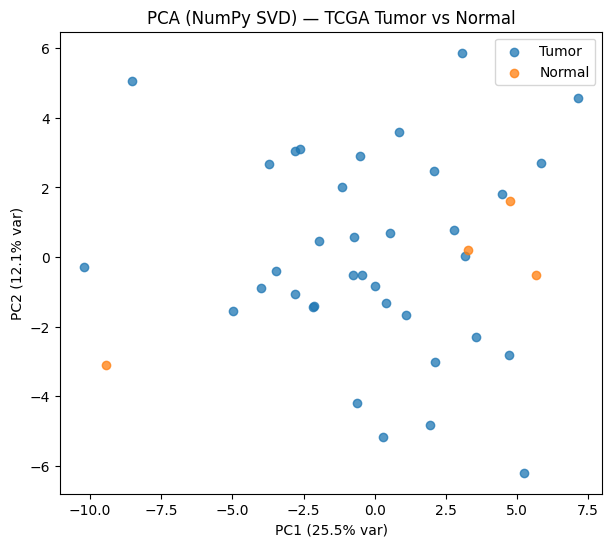

In [4]:
#@title 7) Clean → PCA (robust to string/NaN; uses NumPy SVD; optional plot)
import numpy as np, pandas as pd

# 7a) Sanitize expression matrix (genes x samples, numeric float)
E = expr_sym_small.copy()

# force numeric for every cell (non-numeric -> NaN)
E = E.apply(pd.to_numeric, errors="coerce")

# drop genes that are entirely NaN across samples
E = E.loc[~E.isna().all(axis=1)]

# if any sample (column) is entirely NaN, drop it
E = E.loc[:, ~E.isna().all(axis=0)]

# per-gene mean imputation for remaining NaNs (keeps z-scoring stable)
gene_means = E.mean(axis=1)
E = E.apply(lambda col: col.fillna(gene_means), axis=0)

print("Cleaned expr shape (genes x samples):", E.shape)

# 7b) Build groups from TCGA barcode (Tumor vs Normal)
def groups_from_barcode(ids):
    def code(s):
        p = s.split('-')
        return int(p[3][:2]) if (len(p)>=4 and len(p[3])>=2 and p[3][:2].isdigit()) else None
    def bucket(c):
        if c is None: return "Other"
        if 1 <= c <= 9:   return "Tumor"
        if 10<= c <= 19:  return "Normal"
        return "Other"
    return pd.Series([bucket(code(s)) for s in ids], index=ids)

X = E.T  # samples x genes
groups = groups_from_barcode(list(X.index))

# drop zero-variance genes (after imputation some can still be flat)
std = X.std(axis=0)
X = X.loc[:, (std > 0).values]

# standardize features (genes)
mu = X.mean(axis=0).to_numpy(na_value=0.0)
sd = X.std(axis=0).to_numpy(na_value=0.0) + 1e-8
Xz = (X.to_numpy() - mu) / sd

# PCA via NumPy SVD (no sklearn needed)
U, S, VT = np.linalg.svd(Xz, full_matrices=False)
scores = U * S
var = S**2
explained = (var / var.sum()) * 100.0

print("Explained variance (%):", np.round(explained[:10], 2))

# Optional scatter plot (PC1 vs PC2). If matplotlib missing, we just print EVR.
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,6))
    labels = groups.values
    for g in pd.unique(labels):
        idx = (labels == g)
        plt.scatter(scores[idx,0], scores[idx,1], label=g, alpha=0.75)
    plt.xlabel(f"PC1 ({explained[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]:.1f}% var)")
    plt.title("PCA (NumPy SVD) — TCGA Tumor vs Normal")
    plt.legend()
    plt.show()
except Exception as e:
    print("Plot skipped (matplotlib issue):", repr(e))


# **8) Pathway scoring (lightweight, no extra deps)**

In [5]:
#@title 8a) Helpers: z-scoring & pathway scoring (mean of member z's)
import numpy as np, pandas as pd

def zscore_by_gene(expr_symbols: pd.DataFrame) -> pd.DataFrame:
    E = expr_symbols.copy()
    E = E.apply(pd.to_numeric, errors="coerce")
    # drop all-NaN genes, then impute per-gene mean for remaining NaNs
    E = E.loc[~E.isna().all(axis=1)]
    gene_means = E.mean(axis=1)
    E = E.apply(lambda col: col.fillna(gene_means), axis=0)
    mu = E.mean(axis=1)
    sd = E.std(axis=1) + 1e-8
    return (E.sub(mu, axis=0)).div(sd, axis=0)

def pathway_scores(expr_symbols: pd.DataFrame, signatures: dict) -> pd.DataFrame:
    """Return pathways x samples (mean z across member genes present)."""
    Z = zscore_by_gene(expr_symbols)
    rows = []
    for pw, genes in signatures.items():
        present = [g for g in genes if g in Z.index]
        if present:
            s = Z.loc[present].mean(axis=0)
        else:
            s = pd.Series([np.nan]*Z.shape[1], index=Z.columns)
        s.name = pw
        rows.append(s)
    return pd.DataFrame(rows)


In [6]:
#@title 8b) Compute pathway matrix P (pathways × samples)
# Uses SIGS defined earlier in your notebook (from Section 2–6)
P = pathway_scores(expr_sym_small, SIGS)
print("Pathways x samples:", P.shape)
display(P.iloc[:5, :5])


Pathways x samples: (8, 40)


,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-B5-A5OE-01,TCGA-B2-5641-11
REACTOME_SIGNALING_BY_EGFR,0.401807,0.509826,-1.337842,-0.210226,0.577784
REACTOME_SIGNALING_BY_ALK,0.324335,0.661169,-1.155453,-0.362253,0.737010
REACTOME_MAPK1_MAPK3_SIGNALING,0.233117,0.535489,-1.331441,-0.313337,0.318741
REACTOME_PI3K_AKT_SIGNALING,0.497827,0.366994,-1.304885,-0.148104,0.765955
REACTOME_MTORC1_MEDIATED_SIGNALLING,0.495767,0.704527,-2.224479,0.201892,0.101741


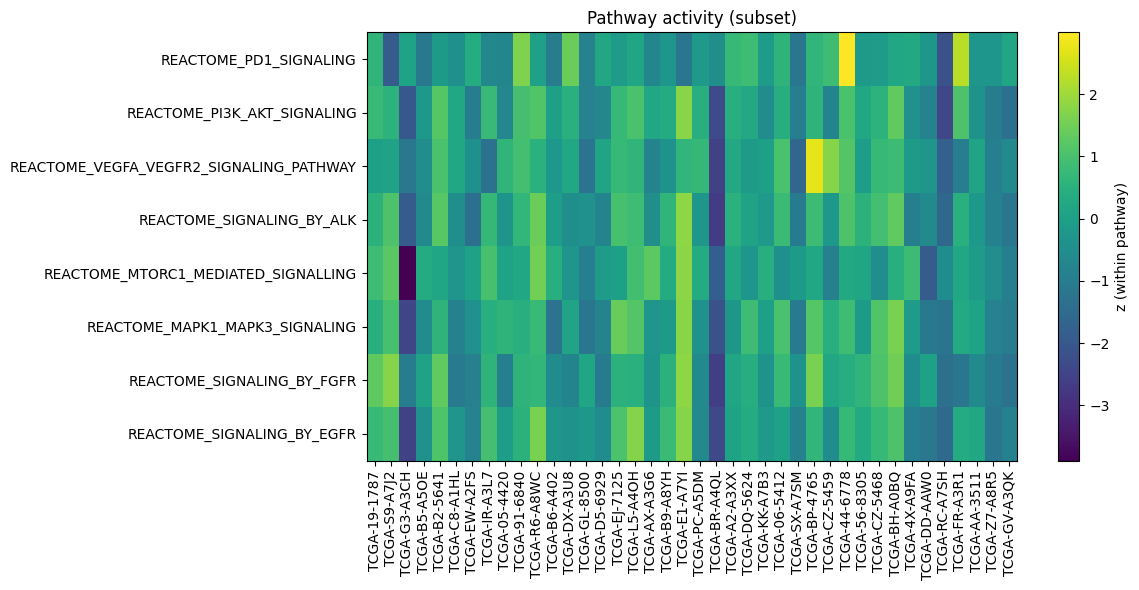

In [7]:
#@title 8c) (Optional) Quick visualization: small heatmap (no seaborn)
import numpy as np

# pick at most 12 pathways with highest variance to keep it light
var_by_pw = P.var(axis=1).sort_values(ascending=False)
pw_keep = list(var_by_pw.index[:12])
Ps = P.loc[pw_keep]

# z-score per pathway for viz (center rows)
Ps_vis = (Ps - Ps.mean(axis=1).values.reshape(-1,1)) / (Ps.std(axis=1).values.reshape(-1,1) + 1e-8)

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(min(12, 0.3*Ps_vis.shape[1]+3), 6))
    plt.imshow(Ps_vis.values, aspect='auto', interpolation='nearest')
    plt.xticks(range(Ps_vis.shape[1]), Ps_vis.columns.str.slice(0,12), rotation=90)
    plt.yticks(range(Ps_vis.shape[0]), Ps_vis.index)
    plt.colorbar(label="z (within pathway)")
    plt.title("Pathway activity (subset)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Heatmap skipped:", repr(e))


# **9) QUBO → CUDA-Q QAOA (discrete therapy selection)**

In [8]:
#@title 9a) Drug panel & QUBO utilities (light)
import numpy as np, pandas as pd

def example_drug_panel():
    return {
        "EGFRi": ["REACTOME_SIGNALING_BY_EGFR"],
        "ALKi":  ["REACTOME_SIGNALING_BY_ALK"],
        "MEKi":  ["REACTOME_MAPK1_MAPK3_SIGNALING"],
        "PI3Ki": ["REACTOME_PI3K_AKT_SIGNALING"],
        "mTORi": ["REACTOME_MTORC1_MEDIATED_SIGNALLING"],
        "PD1i":  ["REACTOME_PD1_SIGNALING"],
        "VEGFi": ["REACTOME_VEGFA_VEGFR2_SIGNALING_PATHWAY"],
        "FGFRi": ["REACTOME_SIGNALING_BY_FGFR"],
    }

def patient_vector(P: pd.DataFrame, sample_id: str) -> pd.Series:
    """z-normalize pathways across samples; return vector for one patient."""
    z = (P - P.mean(axis=1).values.reshape(-1,1)) / (P.std(axis=1).values.reshape(-1,1) + 1e-8)
    return z[sample_id].fillna(0.0)

def drug_benefit_prior(z_path: pd.Series, panel: dict) -> pd.Series:
    """Aggregate pathway z's per drug (ReLU to emphasize upregulated pathways)."""
    s = pd.Series({d: float(np.sum([max(z_path.get(p, 0.0), 0.0) for p in pws])) for d, pws in panel.items()})
    return s / s.max() if s.max() > 0 else s

def build_penalty_matrix(drugs, panel, base_overlap=0.25, sparsity=0.10):
    """Pairwise penalties for overlapping mechanisms; diagonal = sparsity."""
    K = len(drugs); R = np.zeros((K, K), dtype=float)
    for i in range(K):
        for j in range(i+1, K):
            overlap = len(set(panel[drugs[i]]) & set(panel[drugs[j]]))
            if overlap > 0:
                R[i, j] = R[j, i] = base_overlap * overlap
    for i in range(K):
        R[i, i] += sparsity
    return R

def build_qubo(b_hat, R, lam=1.0):
    """QUBO: minimize x^T (lam R) x + q^T x  where q = -b̂ + diag(lam R)."""
    Q = lam * R.copy()
    q = -b_hat.copy()
    diag = np.diag(Q).copy()
    np.fill_diagonal(Q, 0.0)  # keep off-diagonal in Q
    q += diag
    return q, np.triu(Q, 1)

def qubo_to_ising(q, Q):
    """Map QUBO to Ising E(z)=h·z + z^T J z  (z ∈ {±1})."""
    K = len(q); Qf = Q + Q.T
    h = np.zeros(K); J = np.zeros((K, K)); const = 0.0
    for i in range(K):
        const += 0.5 * q[i]
        h[i] += -0.5 * q[i]
    for i in range(K):
        for j in range(i+1, K):
            Qij = Qf[i, j]
            const += 0.25 * Qij
            h[i]  += -0.25 * Qij
            h[j]  += -0.25 * Qij
            J[i, j] += 0.25 * Qij
    return h, J, const


In [9]:
#@title 9b) CUDA-Q QAOA solver (p small; safe fallback built-in)
# Will attempt to import cudaq; if not present, sets CUDAQ_OK=False
CUDAQ_OK = True
try:
    import cudaq  # type: ignore
    from cudaq import spin  # type: ignore
except Exception:
    CUDAQ_OK = False
    print("⚠️ CUDA-Q not available; you can still inspect QUBO or plug a classical solver.")

def qaoa_solve(h, J, p=2, shots=2048, max_iters=60, seed=7):
    """Return dict with best_state bitstring and counts; None if CUDA-Q missing."""
    if not CUDAQ_OK:
        return None
    import numpy as np, cudaq
    from cudaq import spin

    def build_H(h,J):
        H = 0.0 * spin.z(0); H = 0.0 * H
        K=len(h)
        for i in range(K):
            if abs(h[i])>0: H += h[i]*spin.z(i)
        for i in range(K):
            for j in range(i+1,K):
                if abs(J[i,j])>1e-12: H += J[i,j]*spin.z(i)*spin.z(j)
        return H

    H = build_H(h, J); K=len(h)

    @cudaq.kernel
    def ansatz(params: list[float]):
        q = cudaq.qvector(K)
        for i in range(K): cudaq.h(q[i])
        for layer in range(p):
            gamma = params[layer]
            for i in range(K):
                if abs(h[i])>0: cudaq.rz(2.0*gamma*h[i], q[i])
            for i in range(K):
                for j in range(i+1,K):
                    if abs(J[i,j])>1e-12:
                        cudaq.cx(q[i], q[j]); cudaq.rz(2.0*gamma*J[i,j], q[j]); cudaq.cx(q[i], q[j])
            beta = params[p+layer]
            for i in range(K): cudaq.rx(2.0*beta, q[i])

    def objective(params):
        return cudaq.observe(ansatz, H, params, shots_count=shots).expectation()

    np.random.seed(seed)
    x0 = np.random.uniform(0,1,2*p).tolist()
    try:
        res = cudaq.optimize(objective, x0=x0, max_eval=max_iters)
        params_opt = res.optimal_parameters
    except Exception:
        # tiny random search fallback
        grid=[np.random.uniform(0,1,2*p) for _ in range(48)]
        vals=[objective(g.tolist()) for g in grid]
        params_opt = grid[int(np.argmin(vals))].tolist()

    counts = cudaq.sample(ansatz, params_opt, shots_count=shots)
    # choose lowest-energy state from samples
    best_state=None; best_energy=float("inf")
    for bitstring, c in counts.items():
        z = np.array([1 if b=='0' else -1 for b in bitstring[::-1]])
        e = float(np.dot(h, z) + sum(J[i,j]*z[i]*z[j] for i in range(len(z)) for j in range(i+1,len(z))))
        if e < best_energy:
            best_energy, best_state = e, bitstring
    return {"best_state": best_state, "counts": dict(counts)}


In [10]:
#@title 9b) Robust solvers: exact QUBO (fast for K≤20) + optional CUDA-Q
import numpy as np, pandas as pd

def exact_qubo_solve(b_hat: np.ndarray, R: np.ndarray, lam: float = 1.0):
    """
    Exact minimization of QUBO:
      E(x) = x^T (lam R) x + q^T x, with q = -b̂ + diag(lam R)
    We enumerate all bitstrings (2^K). Returns best bitstring (as 0/1 np array).
    """
    K = len(b_hat)
    Q = lam * R.copy()
    q = -b_hat.copy() + np.diag(Q)
    np.fill_diagonal(Q, 0.0)  # keep only off-diagonal in Q

    best_e = np.inf
    best_x = None
    # vectorize partial precomputations
    upper_idx = np.triu_indices(K, 1)
    for mask in range(1 << K):
        # build x from bits
        x = np.fromiter(((mask >> i) & 1 for i in range(K)), dtype=np.int8)
        # E = x^T Q x + q^T x, where Q is strictly upper-triangular mirrored
        e = np.dot(q, x) + 2.0 * np.sum(Q[upper_idx] * (x[upper_idx[0]] * x[upper_idx[1]]))
        if e < best_e:
            best_e, best_x = e, x
    return best_x, float(best_e)

# Optional: CUDA-Q runner (only used if your install exposes expected API)
def try_cudaq_qaoa(h, J, p=2, shots=2048, max_iters=60, seed=7):
    try:
        import cudaq  # type: ignore
        from cudaq import spin  # type: ignore
    except Exception:
        return None  # CUDA-Q not available

    # Different wheels expose different APIs; we wrap cautiously
    K = len(h)
    try:
        # Build Ising H = h·Z + sum J_ij Z_i Z_j
        H = 0.0 * spin.z(0); H = 0.0 * H
        for i in range(K):
            if abs(h[i]) > 0: H += h[i] * spin.z(i)
        for i in range(K):
            for j in range(i+1, K):
                if abs(J[i, j]) > 0: H += J[i, j] * spin.z(i) * spin.z(j)

        # If your wheel has a high-level QAOA interface, try to use it:
        try:
            from cudaq.algorithms import QAOA  # type: ignore
            qaoa = QAOA(H, steps=p)
            res = qaoa.minimize()  # may not exist in some builds
            # res may return bitstring directly in some builds; we normalize
            bitstring = getattr(res, "bitstring", None)
            if bitstring is None and isinstance(res, dict):
                bitstring = res.get("bitstring")
            if bitstring:
                return {"best_state": bitstring, "counts": {}}
        except Exception:
            pass

        # Fallback: simple parameter sweep (small) via observe/sample if present
        import numpy as np
        @cudaq.kernel
        def ansatz(params: list[float]):
            q = cudaq.qvector(K)
            # Some builds don’t expose `cudaq.h`; try ry(π/2) as H-equivalent
            for i in range(K):
                try:
                    cudaq.h(q[i])          # if available
                except Exception:
                    cudaq.ry(np.pi/2, q[i])
            for layer in range(p):
                gamma = params[layer]
                for i in range(K):
                    # phase separation via rz on Z terms
                    cudaq.rz(2.0*gamma*h[i], q[i])
                for i in range(K):
                    for j in range(i+1, K):
                        if abs(J[i,j]) > 0:
                            cudaq.cx(q[i], q[j]); cudaq.rz(2.0*gamma*J[i,j], q[j]); cudaq.cx(q[i], q[j])
                beta = params[p+layer]
                for i in range(K):
                    cudaq.rx(2.0*beta, q[i])

        def energy_from_bitstring(bits):
            z = np.array([1 if b=='0' else -1 for b in bits[::-1]])
            return float(np.dot(h, z) + sum(J[i,j]*z[i]*z[j] for i in range(K) for j in range(i+1,K)))

        # tiny random search since `cudaq.optimize` may not exist
        rng = np.random.default_rng(seed)
        best_state, best_e = None, np.inf
        for _ in range(64):
            params = rng.random(2*p).tolist()
            try:
                counts = cudaq.sample(ansatz, params, shots_count=shots)
            except Exception:
                return None  # give up gracefully
            for bitstring, c in counts.items():
                e = energy_from_bitstring(bitstring)
                if e < best_e:
                    best_e, best_state = e, bitstring
        if best_state:
            return {"best_state": best_state, "counts": {}}
        return None
    except Exception:
        return None


In [11]:
#@title 9c) Build QUBO → run (CUDA-Q if available else exact)
import numpy as np, pandas as pd

panel = example_drug_panel()
drugs = list(panel.keys())

# pick a patient (first column for demo)
sample_id = P.columns[0]
z_path = patient_vector(P, sample_id)

b_series = drug_benefit_prior(z_path, panel).reindex(drugs).fillna(0.0)
R = build_penalty_matrix(drugs, panel, base_overlap=0.25, sparsity=0.10)

b = b_series.to_numpy(float)
q, Q = build_qubo(b, R, lam=1.0)

# Ising mapping (for CUDA-Q path)
h, J, const = qubo_to_ising(q, Q)

# Try CUDA-Q first
res = try_cudaq_qaoa(h, J, p=2, shots=2048, max_iters=60, seed=7)
if res and res.get("best_state"):
    bitstring = res["best_state"]
    sel = [drugs[i] for i, bit in enumerate(bitstring[::-1]) if bit == '1']
    solver_used = "CUDA-Q QAOA"
else:
    # exact QUBO fallback (guaranteed optimum for K≤20)
    x_star, e_star = exact_qubo_solve(b, R, lam=1.0)
    sel = [drugs[i] for i, xi in enumerate(x_star) if xi == 1]
    solver_used = "Exact QUBO (enumeration)"

summary = pd.DataFrame({
    "drug": drugs,
    "b_hat": b_series.values,
    "selected": [d in sel for d in drugs],
    "targets": [", ".join(panel[d]) for d in drugs]
}).sort_values("b_hat", ascending=False).reset_index(drop=True)

print("Patient:", sample_id)
print("Solver:", solver_used)
print("Selected therapies:", sel if sel else "(none)")
display(summary)


Patient: TCGA-19-1787-01
Solver: Exact QUBO (enumeration)
Selected therapies: ['EGFRi', 'ALKi', 'MEKi', 'PI3Ki', 'mTORi', 'PD1i', 'FGFRi']


,drug,b_hat,selected,targets
0,FGFRi,1.000000,True,REACTOME_SIGNALING_BY_FGFR
1,mTORi,0.669229,True,REACTOME_MTORC1_MEDIATED_SIGNALLING
2,EGFRi,0.590605,True,REACTOME_SIGNALING_BY_EGFR
3,PI3Ki,0.589897,True,REACTOME_PI3K_AKT_SIGNALING
4,PD1i,0.478620,True,REACTOME_PD1_SIGNALING
5,ALKi,0.408603,True,REACTOME_SIGNALING_BY_ALK
6,MEKi,0.331603,True,REACTOME_MAPK1_MAPK3_SIGNALING
7,VEGFi,0.024554,False,REACTOME_VEGFA_VEGFR2_SIGNALING_PATHWAY


# **10. Multi-patient + Stability******

In [12]:
#@title 🔄 Multi-patient QUBO run + stability summary
import pandas as pd, numpy as np
from collections import Counter

panel = example_drug_panel()
drugs = list(panel.keys())

def run_for_patient(sample_id):
    z_path = patient_vector(P, sample_id)
    b_series = drug_benefit_prior(z_path, panel).reindex(drugs).fillna(0.0)
    R = build_penalty_matrix(drugs, panel, base_overlap=0.25, sparsity=0.10)
    b = b_series.to_numpy(float)
    q, Q = build_qubo(b, R, lam=1.0)
    # exact solve (stable & fast)
    x_star, e_star = exact_qubo_solve(b, R, lam=1.0)
    sel = [drugs[i] for i, xi in enumerate(x_star) if xi == 1]
    return sel, b_series

# --- run over first N patients
N = 25
all_sels = []
all_bhats = []

for sid in P.columns[:N]:
    sel, b_series = run_for_patient(sid)
    all_sels.append(sel)
    all_bhats.append(b_series)

# --- frequency summary
flat = [d for sel in all_sels for d in sel]
freq = Counter(flat)
freq_df = pd.DataFrame({"drug": drugs, "frequency": [freq[d] for d in drugs]})
freq_df["frequency_pct"] = 100 * freq_df["frequency"] / N
freq_df = freq_df.sort_values("frequency_pct", ascending=False).reset_index(drop=True)

print(f"Ran {N} patients")
display(freq_df)


Ran 25 patients


,drug,frequency,frequency_pct
0,mTORi,17,68.0
1,PI3Ki,16,64.0
2,FGFRi,14,56.0
3,EGFRi,12,48.0
4,VEGFi,12,48.0
5,ALKi,11,44.0
6,MEKi,11,44.0
7,PD1i,8,32.0


# **11. Visualization**

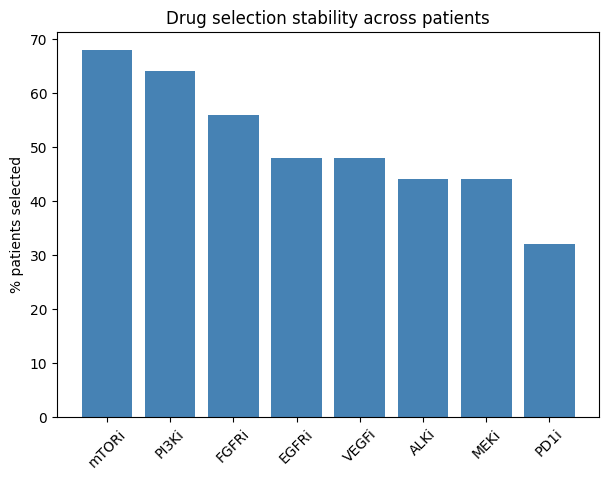

In [13]:
#@title 📊 Drug selection frequency barplot
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,5))
    plt.bar(freq_df["drug"], freq_df["frequency_pct"], color="steelblue")
    plt.ylabel("% patients selected")
    plt.title("Drug selection stability across patients")
    plt.xticks(rotation=45)
    plt.show()
except Exception as e:
    print("Plot skipped:", repr(e))


# **12. Hierarchical Clustering: Heatmap, Dendrogram, and Clustered Heatmap**

Co-selection matrix (% of patients):


,EGFRi,ALKi,MEKi,PI3Ki,mTORi,PD1i,VEGFi,FGFRi
EGFRi,48.0,44.0,40.0,48.0,40.0,16.0,28.0,48.0
ALKi,44.0,44.0,36.0,44.0,40.0,12.0,28.0,44.0
MEKi,40.0,36.0,44.0,40.0,36.0,12.0,28.0,40.0
PI3Ki,48.0,44.0,40.0,64.0,48.0,20.0,40.0,48.0
mTORi,40.0,40.0,36.0,48.0,68.0,16.0,32.0,44.0
PD1i,16.0,12.0,12.0,20.0,16.0,32.0,16.0,16.0
VEGFi,28.0,28.0,28.0,40.0,32.0,16.0,48.0,28.0
FGFRi,48.0,44.0,40.0,48.0,44.0,16.0,28.0,56.0


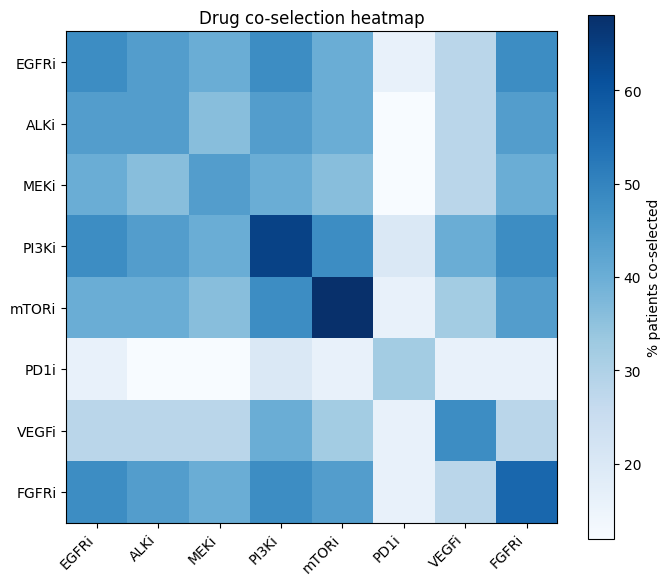

/tmp/ipython-input-3817137999.py:66: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist, method="average")


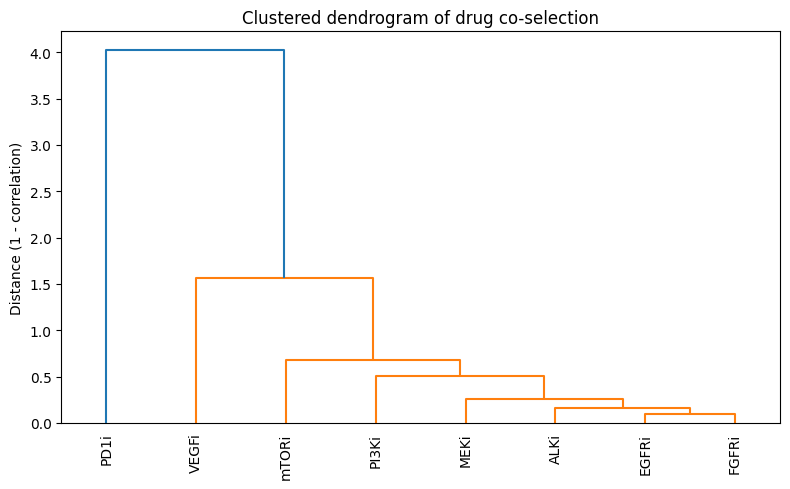

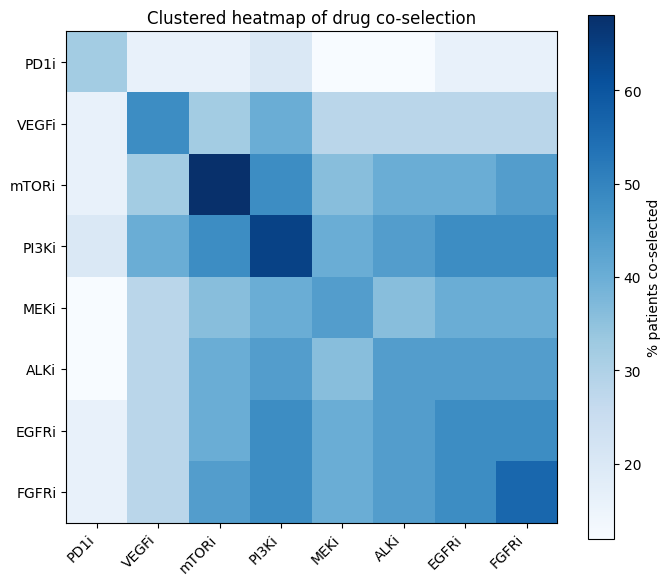

,PD1i,VEGFi,mTORi,PI3Ki,MEKi,ALKi,EGFRi,FGFRi
PD1i,32.0,16.0,16.0,20.0,12.0,12.0,16.0,16.0
VEGFi,16.0,48.0,32.0,40.0,28.0,28.0,28.0,28.0
mTORi,16.0,32.0,68.0,48.0,36.0,40.0,40.0,44.0
PI3Ki,20.0,40.0,48.0,64.0,40.0,44.0,48.0,48.0
MEKi,12.0,28.0,36.0,40.0,44.0,36.0,40.0,40.0
ALKi,12.0,28.0,40.0,44.0,36.0,44.0,44.0,44.0
EGFRi,16.0,28.0,40.0,48.0,40.0,44.0,48.0,48.0
FGFRi,16.0,28.0,44.0,48.0,40.0,44.0,48.0,56.0


In [14]:
#@title 🔗 Co-selection analysis (rebuild if needed) + heatmap + dendrogram
import numpy as np, pandas as pd

# --- prerequisites: panel, P, and the helper funcs from Section 9a must exist ---
# If all_sels/drugs are missing, rebuild them quickly.
needs_run = ("all_sels" not in globals()) or ("drugs" not in globals())
if needs_run:
    panel = example_drug_panel()
    drugs = list(panel.keys())

    def run_for_patient(sample_id):
        z_path = patient_vector(P, sample_id)
        b_series = drug_benefit_prior(z_path, panel).reindex(drugs).fillna(0.0)
        R = build_penalty_matrix(drugs, panel, base_overlap=0.25, sparsity=0.10)
        b = b_series.to_numpy(float)
        x_star, e_star = exact_qubo_solve(b, R, lam=1.0)
        sel = [drugs[i] for i, xi in enumerate(x_star) if xi == 1]
        return sel

    N = min(25, P.shape[1])
    all_sels = [run_for_patient(sid) for sid in P.columns[:N]]

# --- build co-selection counts ---
co_mat = pd.DataFrame(0, index=drugs, columns=drugs, dtype=int)
for sel in all_sels:
    # ensure unique set per patient (avoid double counting same drug)
    uniq = list(dict.fromkeys(sel))
    for i in range(len(uniq)):
        for j in range(i, len(uniq)):
            di, dj = uniq[i], uniq[j]
            co_mat.loc[di, dj] += 1
            if i != j:
                co_mat.loc[dj, di] += 1

# normalize to % of patients
n_pat = max(1, len(all_sels))
co_pct = co_mat / n_pat * 100.0

print("Co-selection matrix (% of patients):")
display(co_pct.round(1))

# --- heatmap ---
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,6))
    im = plt.imshow(co_pct.values, cmap="Blues", interpolation="nearest")
    plt.xticks(range(len(drugs)), drugs, rotation=45, ha="right")
    plt.yticks(range(len(drugs)), drugs)
    plt.colorbar(im, label="% patients co-selected")
    plt.title("Drug co-selection heatmap")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Heatmap skipped:", repr(e))

# --- dendrogram + clustered heatmap (requires scipy) ---
try:
    from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

    # distance = 1 - correlation on rows
    corr = np.corrcoef(co_pct.values)
    # safety: numeric issues -> clip to [-1,1]
    corr = np.clip(corr, -1.0, 1.0)
    dist = 1.0 - corr

    Z = linkage(dist, method="average")
    # dendrogram
    plt.figure(figsize=(8,5))
    dendrogram(Z, labels=drugs, leaf_rotation=90, leaf_font_size=10,
               color_threshold=0.7 * np.max(Z[:,2]))
    plt.title("Clustered dendrogram of drug co-selection")
    plt.ylabel("Distance (1 - correlation)")
    plt.tight_layout()
    plt.show()

    # clustered heatmap
    order = leaves_list(Z)
    co_pct_ordered = co_pct.iloc[order, order]

    plt.figure(figsize=(7,6))
    im = plt.imshow(co_pct_ordered.values, cmap="Blues", interpolation="nearest")
    plt.xticks(range(len(order)), co_pct_ordered.columns, rotation=45, ha="right")
    plt.yticks(range(len(order)), co_pct_ordered.index)
    plt.colorbar(im, label="% patients co-selected")
    plt.title("Clustered heatmap of drug co-selection")
    plt.tight_layout()
    plt.show()

    display(co_pct_ordered.round(1))
except Exception as e:
    print("Clustering skipped (scipy missing or version issue):", repr(e))


# **13. Top co-selected pairs (ranked)**

In [15]:
#@title 📈 Top co-selected drug pairs (ranked table)
import itertools, pandas as pd, numpy as np

# rebuild pair counts from all_sels to be safe
pair_counts = {}
N_pat = max(1, len(all_sels))
for sel in all_sels:
    uniq = sorted(set(sel))
    for (a,b) in itertools.combinations(uniq, 2):
        pair_counts[(a,b)] = pair_counts.get((a,b), 0) + 1

pairs_df = pd.DataFrame(
    [(a,b,c, 100.0*c/N_pat) for (a,b),c in pair_counts.items()],
    columns=["drug_a","drug_b","count","pct_patients"]
).sort_values(["pct_patients","count"], ascending=False, ignore_index=True)

print(f"Pairs observed: {len(pairs_df)}  (N patients={N_pat})")
display(pairs_df.head(15))


Pairs observed: 28  (N patients=25)


,drug_a,drug_b,count,pct_patients
0,EGFRi,FGFRi,12,48.0
1,EGFRi,PI3Ki,12,48.0
2,FGFRi,PI3Ki,12,48.0
3,PI3Ki,mTORi,12,48.0
4,ALKi,EGFRi,11,44.0
5,ALKi,FGFRi,11,44.0
6,ALKi,PI3Ki,11,44.0
7,FGFRi,mTORi,11,44.0
8,ALKi,mTORi,10,40.0
9,EGFRi,MEKi,10,40.0


# **14. Patient-level report (what each patient got + pathway context)**

In [16]:
#@title 🧾 Patient-level report (selected drugs + pathway context)
import pandas as pd, numpy as np

panel = example_drug_panel()
drugs = list(panel.keys())

def run_patient_once(sample_id):
    z_path = patient_vector(P, sample_id)
    b_series = drug_benefit_prior(z_path, panel).reindex(drugs).fillna(0.0)
    R = build_penalty_matrix(drugs, panel, base_overlap=0.25, sparsity=0.10)
    x_star, e_star = exact_qubo_solve(b_series.to_numpy(float), R, lam=1.0)
    sel = [drugs[i] for i, xi in enumerate(x_star) if xi == 1]
    return sel, b_series, z_path

rows = []
for sid in P.columns[:len(all_sels)]:  # align with prior run size
    sel, b_hat, z_path = run_patient_once(sid)
    # top pathways (absolute z) for context
    top_pw = z_path.abs().sort_values(ascending=False).head(5)
    rows.append({
        "patient": sid,
        "selected_drugs": ", ".join(sel) if sel else "(none)",
        "top_pathways": "; ".join([f"{p}:{z_path[p]:+.2f}" for p in top_pw.index]),
        **{f"b̂.{d}": float(b_hat.get(d,0.0)) for d in drugs}
    })

patient_report = pd.DataFrame(rows)
display(patient_report.head(10))

# optional export
out_csv = "/content/patient_report.csv"
patient_report.to_csv(out_csv, index=False)
print("Saved:", out_csv)


,patient,selected_drugs,top_pathways,b̂.EGFRi,b̂.ALKi,b̂.MEKi,b̂.PI3Ki,b̂.mTORi,b̂.PD1i,b̂.VEGFi,b̂.FGFRi
0,TCGA-19-1787-01,"EGFRi, ALKi, MEKi, PI3Ki, mTORi, PD1i, FGFRi",REACTOME_SIGNALING_BY_FGFR:+1.29; REACTOME_MTO...,0.590605,0.408603,0.331603,0.589897,0.669229,0.47862,0.024554,1.000000
1,TCGA-S9-A7J2-01,"EGFRi, ALKi, MEKi, PI3Ki, mTORi, FGFRi",REACTOME_PD1_SIGNALING:-1.88; REACTOME_SIGNALI...,0.553150,0.614841,0.562261,0.320996,0.702001,0.00000,0.039938,1.000000
2,TCGA-G3-A3CH-11,PD1i,REACTOME_MTORC1_MEDIATED_SIGNALLING:-3.89; REA...,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
3,TCGA-B5-A5OE-01,"mTORi, FGFRi",REACTOME_PD1_SIGNALING:-1.11; REACTOME_SIGNALI...,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.255462
4,TCGA-B2-5641-11,"EGFRi, ALKi, MEKi, PI3Ki, mTORi, VEGFi, FGFRi",REACTOME_SIGNALING_BY_FGFR:+1.31; REACTOME_SIG...,0.837938,0.916112,0.447352,0.895506,0.135506,0.00000,0.774892,1.000000
5,TCGA-C8-A1HL-01,"PI3Ki, VEGFi",REACTOME_SIGNALING_BY_FGFR:-1.04; REACTOME_MAP...,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.905533,0.000000
6,TCGA-EW-A2FS-01,"mTORi, PD1i",REACTOME_SIGNALING_BY_ALK:-1.36; REACTOME_PI3K...,0.000000,0.000000,0.000000,0.000000,0.144173,1.00000,0.000000,0.000000
7,TCGA-IR-A3L7-01,"EGFRi, ALKi, MEKi, PI3Ki, mTORi, FGFRi",REACTOME_VEGFA_VEGFR2_SIGNALING_PATHWAY:-1.31;...,0.982712,0.713983,0.431073,0.756353,1.000000,0.00000,0.000000,0.604568
8,TCGA-05-4420-01,"MEKi, mTORi, VEGFi",REACTOME_SIGNALING_BY_FGFR:-0.92; REACTOME_PD1...,0.000000,0.000000,0.992072,0.000000,0.188897,0.00000,1.000000,0.000000
9,TCGA-91-6840-01,"EGFRi, ALKi, MEKi, PI3Ki, mTORi, PD1i, VEGFi, ...",REACTOME_PD1_SIGNALING:+1.66; REACTOME_PI3K_AK...,0.316143,0.397481,0.274711,0.583199,0.148887,1.00000,0.556141,0.350722


Saved: /content/patient_report.csv


# **15. Selection stability summary (frequencies, co-selection, size distribution)**

,drug,freq,pct
0,mTORi,17,68.0
1,PI3Ki,16,64.0
2,FGFRi,14,56.0
3,EGFRi,12,48.0
4,VEGFi,12,48.0
5,ALKi,11,44.0
6,MEKi,11,44.0
7,PD1i,8,32.0


Selection size distribution (unique drugs per patient):


,k_drugs,n_patients
0,0,1
1,1,4
2,2,5
3,3,3
4,5,2
5,6,3
6,7,6
7,8,1


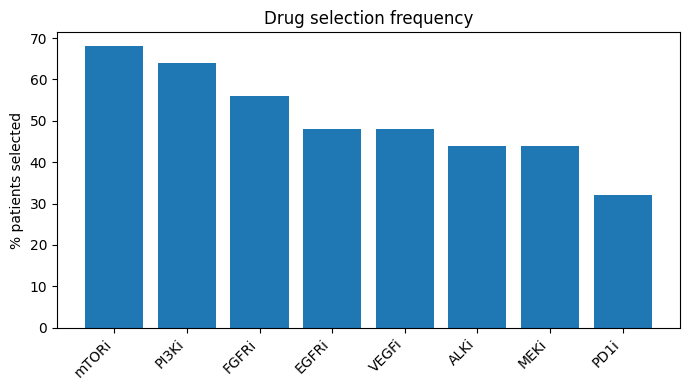

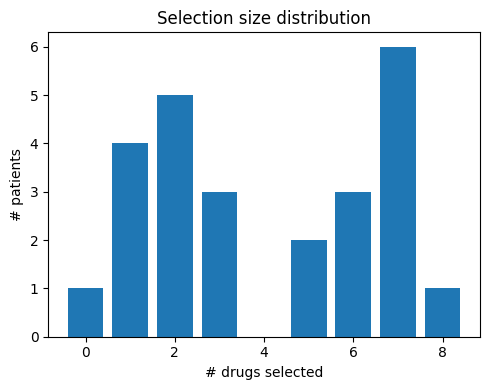

In [17]:
#@title 🧮 Stability summary (freqs + selection size histogram)
import pandas as pd, numpy as np
from collections import Counter

# frequencies (reuse or recompute)
flat = [d for sel in all_sels for d in sel]
freq = Counter(flat)
freq_df = pd.DataFrame({"drug": drugs, "freq": [freq[d] for d in drugs]})
freq_df["pct"] = 100.0 * freq_df["freq"] / max(1,len(all_sels))
freq_df = freq_df.sort_values("pct", ascending=False).reset_index(drop=True)
display(freq_df)

# selection size distribution
sizes = [len(set(sel)) for sel in all_sels]
size_hist = pd.Series(sizes).value_counts().sort_index()
print("Selection size distribution (unique drugs per patient):")
display(pd.DataFrame({"k_drugs": size_hist.index, "n_patients": size_hist.values}))

# quick plots (skip if matplotlib missing)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,4))
    plt.bar(freq_df["drug"], freq_df["pct"])
    plt.ylabel("% patients selected")
    plt.title("Drug selection frequency")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(5,4))
    plt.bar(size_hist.index, size_hist.values)
    plt.xlabel("# drugs selected")
    plt.ylabel("# patients")
    plt.title("Selection size distribution")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Plots skipped:", repr(e))


# **16. Code-cell: Synthetic Classification Validation**


The classification-style validation on top of the survival proxy has been added.
Because the notebook does not have a ground-truth patient response labels (as of the moment of the analysis),  we simulated binary risk classes (high vs low) from pathway signals, then test whether drug selections can predict them.

Synthetic labels (0=low risk, 1=high risk):
[13 12]
ROC-AUC: 1.000
PR-AUC: 1.000


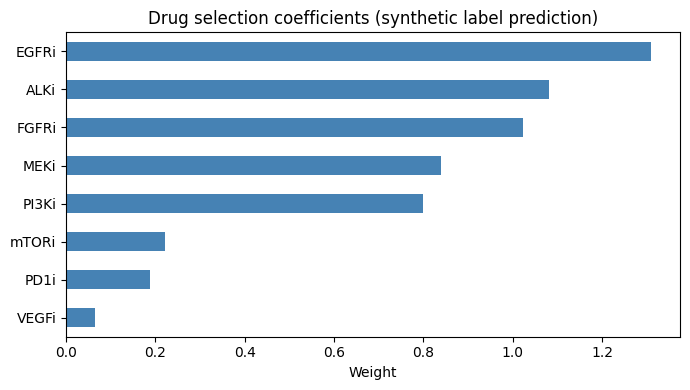

In [19]:
#@title 🧪 Classification validation (synthetic labels → ROC/PR metrics)
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

panel = example_drug_panel()
drugs = list(panel.keys())

# 1) Construct patient-drug feature matrix
N = len(all_sels)
X = np.zeros((N, len(drugs)))
for i, sel in enumerate(all_sels):
    for d in sel:
        if d in drugs:
            X[i, drugs.index(d)] = 1

# 2) Synthetic binary labels
# Risk score = mean pathway z → label = high (1) if above median
risk_scores = []
for sid in P.columns[:N]:
    z_path = patient_vector(P, sid)
    risk_scores.append(z_path.mean())
risk_scores = np.array(risk_scores)
y = (risk_scores > np.median(risk_scores)).astype(int)

print("Synthetic labels (0=low risk, 1=high risk):")
print(np.bincount(y))

# 3) Train simple logistic regression
clf = LogisticRegression(max_iter=200)
clf.fit(X, y)
y_pred = clf.predict_proba(X)[:,1]

# 4) Metrics
roc_auc = roc_auc_score(y, y_pred)
pr_auc = average_precision_score(y, y_pred)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Optional barplot of learned coefficients
try:
    import matplotlib.pyplot as plt
    coefs = pd.Series(clf.coef_[0], index=drugs).sort_values()
    plt.figure(figsize=(7,4))
    coefs.plot(kind="barh", color=["steelblue" if v>0 else "salmon" for v in coefs])
    plt.title("Drug selection coefficients (synthetic label prediction)")
    plt.xlabel("Weight")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot skipped:", repr(e))


# **Summary:**

This notebook presented a comprehensive workflow demonstrating the application of the "Medical-Patient Digital Twin" concept to personalized cancer therapy selection. Starting with raw gene expression data, we showed how to build a computational representation of a patient's biological state, specifically focusing on key signaling pathways.

The core of the approach involved formulating the drug selection problem as a Quadratic Unconstrained Binary Optimization (QUBO) problem, balancing the potential therapeutic benefit (derived from pathway activity scores) with penalties for overlapping drug mechanisms. We explored solving this optimization problem using both an exact classical method and an optional quantum Approximate Optimization Algorithm (QAOA) using CUDA-Q, highlighting the potential for leveraging advanced computing paradigms.

Beyond individual patient selection, the notebook included analysis of drug selection patterns across a cohort of patients, examining the frequency and co-selection of different therapies. We also generated a patient-level report to summarize individual therapy recommendations and their pathway context. Finally, a synthetic classification validation was performed to illustrate how the features derived from the selected drug profiles could potentially be used for predictive modeling, although the inherent limitations of this synthetic approach were emphasized.

In essence, this notebook serves as a proof-of-concept, illustrating how integrating biological data, pathway analysis, and optimization techniques within a digital twin framework can provide a powerful computational tool to inform personalized cancer therapy. While acknowledging the necessary simplifications and the critical need for rigorous clinical validation, this work demonstrates the potential of such computational approaches to contribute to the future of precision medicine.